# INFO 2950 Final Project Phase IV

## Introduction

### Research Questions
Question: Can we accurately predict the daily bike rental sharing count based on the environemntal conditions (weather, temp, hum, windspeed) and if that day is holiday or not.

In this analysis, we aim to explore correlations between daily bike rental counts and various factors, such as weather conditions and holidays. Specifically, we will investigate the relationships between temperature, humidity, wind speed, weather conditions and holiday. We will train a multivariable regression model to see if we can reliably predict the number of daily bike rentals based on these environmental and holiday conditions.

## Data Cleaning

We downloaded the data from UC Irvine Machine Learning Repository in the form of a .csv file. To perform data cleaning, we placed the .csv file in the same folder as our Phase 2, Our first steps are to load the dataset and check for null values.

In [11]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import duckdb
import datetime

In [12]:
# load data
data = pd.read_csv("hour.csv")
data.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


Since we are only interested in the total count of daily bike rentals, we are going to delete the causal and registered user count columns. 


In [13]:
# remove "casual", "registered" column from the data
data = data.drop(data.columns[[-3, -2]], axis=1)
data.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


The description for the workingday column is “if the day is neither weekend nor holiday is 1, otherwise is 0.” Since the workingday column and the weekday and holiday columns are mostly based off of each other, we are going to delete the weekday and holiday columns to simplify the regression model. We do not want a regression model that is too complex and has high variance.

In [14]:
# remove the holiday, weekend column
data = data.drop(['holiday', 'weekday'], axis=1)
data.head()

,instant,dteday,season,yr,mnth,hr,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,2011-01-01,1,0,1,0,0,1,0.24,0.2879,0.81,0.0,16
1,2,2011-01-01,1,0,1,1,0,1,0.22,0.2727,0.80,0.0,40
2,3,2011-01-01,1,0,1,2,0,1,0.22,0.2727,0.80,0.0,32
3,4,2011-01-01,1,0,1,3,0,1,0.24,0.2879,0.75,0.0,13
4,5,2011-01-01,1,0,1,4,0,1,0.24,0.2879,0.75,0.0,1


We find that the dataset contains a column "instant" that works as an index column. We decided to remove this column.

In [15]:
# drop the first column "instant"
data = data.drop(['instant'], axis=1)
data.head()

,dteday,season,yr,mnth,hr,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,2011-01-01,1,0,1,0,0,1,0.24,0.2879,0.81,0.0,16
1,2011-01-01,1,0,1,1,0,1,0.22,0.2727,0.80,0.0,40
2,2011-01-01,1,0,1,2,0,1,0.22,0.2727,0.80,0.0,32
3,2011-01-01,1,0,1,3,0,1,0.24,0.2879,0.75,0.0,13
4,2011-01-01,1,0,1,4,0,1,0.24,0.2879,0.75,0.0,1


We convert the "dteday" column to become a date_time variable column.

In [16]:
data['dteday'] = pd.to_datetime(data['dteday'])

We decided to delete the year column as this is repetitive information from dteday. There are only two years available in this dataframe (2011 and 2012).

In [17]:
data = data.drop(['yr'], axis=1)
data.head()

,dteday,season,mnth,hr,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,2011-01-01,1,1,0,0,1,0.24,0.2879,0.81,0.0,16
1,2011-01-01,1,1,1,0,1,0.22,0.2727,0.80,0.0,40
2,2011-01-01,1,1,2,0,1,0.22,0.2727,0.80,0.0,32
3,2011-01-01,1,1,3,0,1,0.24,0.2879,0.75,0.0,13
4,2011-01-01,1,1,4,0,1,0.24,0.2879,0.75,0.0,1


We decided to divide the "hour" column into four groups:
- first group: hour 0-5 (dawn, 1)
- second group: hour 6-11 (morning, 2)
- third group: hour 12-17 (afternoon, 3)
- fourth group: hour: 18-23 (night, 4)

We realized that the "weathersit" variable may differ among this period of time. However, we could not find the weather situaiton score that occured the most among this time period as there might be multiple situations that occured same amount of time. We decided to take the average of the weather situation then round it to the nearest whole value.

In [18]:
# create a new nolumn called "time_period" that assigns the hours into four groups: 1, 2, 3, 4
data_mod = duckdb.sql("SELECT \
                      CASE \
                      WHEN hr BETWEEN 0 AND 5 THEN 1 \
                      WHEN hr BETWEEN 6 AND 11 THEN 2 \
                      WHEN hr BETWEEN 12 AND 17 THEN 3 \
                      WHEN hr BETWEEN 18 AND 23 THEN 4 \
                      END AS time_period, *\
                      FROM data").df()
data_mod.head(10)

,time_period,dteday,season,mnth,hr,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,2011-01-01,1,1,0,0,1,0.24,0.2879,0.81,0.0000,16
1,1,2011-01-01,1,1,1,0,1,0.22,0.2727,0.80,0.0000,40
2,1,2011-01-01,1,1,2,0,1,0.22,0.2727,0.80,0.0000,32
3,1,2011-01-01,1,1,3,0,1,0.24,0.2879,0.75,0.0000,13
4,1,2011-01-01,1,1,4,0,1,0.24,0.2879,0.75,0.0000,1
5,1,2011-01-01,1,1,5,0,2,0.24,0.2576,0.75,0.0896,1
6,2,2011-01-01,1,1,6,0,1,0.22,0.2727,0.80,0.0000,2
7,2,2011-01-01,1,1,7,0,1,0.20,0.2576,0.86,0.0000,3
8,2,2011-01-01,1,1,8,0,1,0.24,0.2879,0.75,0.0000,8
9,2,2011-01-01,1,1,9,0,1,0.32,0.3485,0.76,0.0000,14


In [19]:
# groupby time_period
# find the average of "weathersit", "temp", "atemp", "hum", "windspeed" in the time period
# and find the sum of total bike rental count occured in this time period
data_clean = duckdb.sql("SELECT time_period, dteday, season, mnth, workingday, \
                        AVG(weathersit) AS weathersit_score, \
                        AVG(temp) AS temp, \
                        AVG(atemp) AS atemp, \
                        AVG(hum) AS hum, \
                        AVG(windspeed) AS windspeed, \
                        SUM(cnt) AS cnt \
                        FROM data_mod \
                        GROUP BY dteday, season, mnth, workingday, time_period \
                        ORDER BY dteday, time_period").df()
data_clean.head(10)

,time_period,dteday,season,mnth,workingday,weathersit_score,temp,atemp,hum,windspeed,cnt
0,1,2011-01-01,1,1,0,1.166667,0.233333,0.277783,0.776667,0.014933,103.0
1,2,2011-01-01,1,1,0,1.000000,0.286667,0.315650,0.790000,0.089550,119.0
2,3,2011-01-01,1,1,0,1.833333,0.440000,0.439367,0.770000,0.291050,554.0
3,4,2011-01-01,1,1,0,2.333333,0.416667,0.421700,0.886667,0.246250,209.0
4,1,2011-01-02,1,1,0,2.000000,0.448000,0.445420,0.940000,0.244760,52.0
5,2,2011-01-02,1,1,0,2.333333,0.386667,0.386350,0.753333,0.236317,154.0
6,3,2011-01-02,1,1,0,2.333333,0.350000,0.338367,0.695000,0.191533,442.0
7,4,2011-01-02,1,1,0,1.166667,0.283333,0.260100,0.436667,0.320917,153.0
8,1,2011-01-03,1,1,1,1.000000,0.185000,0.159125,0.455000,0.361950,11.0
9,2,2011-01-03,1,1,1,1.000000,0.160000,0.141433,0.460000,0.305983,431.0


In [20]:
# round the weathersit to its closest whole number
# then convert it back to int
data_clean['weathersit_score'] = round(data_clean['weathersit_score'])
data_clean['weathersit_score'] = data_clean['weathersit_score'].astype(int)
data_clean.head(10)

,time_period,dteday,season,mnth,workingday,weathersit_score,temp,atemp,hum,windspeed,cnt
0,1,2011-01-01,1,1,0,1,0.233333,0.277783,0.776667,0.014933,103.0
1,2,2011-01-01,1,1,0,1,0.286667,0.315650,0.790000,0.089550,119.0
2,3,2011-01-01,1,1,0,2,0.440000,0.439367,0.770000,0.291050,554.0
3,4,2011-01-01,1,1,0,2,0.416667,0.421700,0.886667,0.246250,209.0
4,1,2011-01-02,1,1,0,2,0.448000,0.445420,0.940000,0.244760,52.0
5,2,2011-01-02,1,1,0,2,0.386667,0.386350,0.753333,0.236317,154.0
6,3,2011-01-02,1,1,0,2,0.350000,0.338367,0.695000,0.191533,442.0
7,4,2011-01-02,1,1,0,1,0.283333,0.260100,0.436667,0.320917,153.0
8,1,2011-01-03,1,1,1,1,0.185000,0.159125,0.455000,0.361950,11.0
9,2,2011-01-03,1,1,1,1,0.160000,0.141433,0.460000,0.305983,431.0


## Data Description

### What are the observations (rows) and the attributes (columns)?

The observations (rows) represent a particular time period each day from 2011 and 2012 in the Capital bikeshare system of bike-sharing data, where the weather, seasonal information, and the number of bike rentals is recorded.

The attributes (columns) includes:
- time_period: 
    - 1: Hour 0-5 (dawn)
    - 2: Hour 6-11 (morning)
    - 3: Hour 12-17 (afternoon)
    - 4: Hour: 18-23 (night)	
- dteday: date
- season: 
    - 1: Spring
    - 2: Summer
    - 3: Fall
    - 4: Winter
- mnth: month ( 1 to 12)
- workingday: if day is neither weekend nor holiday is 1, otherwise is 0.
- weathersit_score:
    - 1: Clear, Few clouds, Partly cloudy, Partly cloudy
    - 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
    - 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
    - 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
- temp: Normalized temperature in Celsius. The values are divided to 41 (max)	
- atemp: Normalized feeling temperature in Celsius. The values are divided to 50 (max)
- hum: Normalized humidity. The values are divided to 100 (max)	
- windspeed: Normalized wind speed. The values are divided to 67 (max)	
- cnt: count of total rental bikes including both casual and registered


### Why was this dataset created?

Hadi Fanaee-T and Joao Gama created this dataset to study how the number of bike rentals are influenced by various factors, including time and environmental conditions. It was used to develop models to predict the demand of bike-sharing, which is useful for planning and improving current bike-sharing systems.

### Who funded the creation of the dataset?

The creation of the bike-sharing dataset was funded by these sources:
1. European Regional Development Fund through the COMPETE Program.
2. Portuguese Funds through the Portuguese Foundation for Science and Technology (FCT) within the project FCOMP — 01-0124-FEDER-022701.
3. European Commission through the project MAESTRA (Grant Number ICT-2013-612944).


### What processes might have influenced what data was observed and recorded and what was not?


Since the data is related to a 2-year usage log of Capital Bike Sharing (CBS) at Washington, D.C., USA , the types of data observed and recorded are mostly for operational purposes. For example, the number of bikes rented per day was recorded for tracking and usage. CBS also needed to consider user privacy, so information such as user description and live bicycle location were not recorded.

### What preprocessing was done, and how did the data come to be in the form that you are using?


The authors normalized values for temperature, humidity, and wind speed to help the model reduce variance between different environmental variables. Additionally, my team and I deleted some attributes (columns) that we feel would be correlated with other attributes. We also transformed the observations (rows) from every hour to every time period (every six hours) because our results would be more interpretable to more readers. When transforming the hour data, we also transformed the weather data to be averaged out between the aggregated hours. 

### If people are involved, were they aware of the data collection and if so, what purpose did they expect the data to be used for?


The bikeshare users were probably not explicitly aware, but had a slight idea, that certain data from them was being collected. We believe these riders agreed to the general collection of data when using CBS by a terms and conditions agreement, which people usually skip through and agree. Generally, users would likely expect the data to be anonymized and used for operational improvements purposes. 


### Where can your raw source data be found, if applicable? Provide a link to the raw data (hosted on Github, in a Cornell Google Drive or Cornell Box)


Not applicable. We found our dataset on UCI Machine Learning Repository. 


## Preregistration Statements

### Statement 1

### Statement 2
Hypothesis 2: Workingday status affects bike rental counts, with fewer rentals expected during non-workdays. 

Analysis: We will run a linear regression with workingday status as a dummy variable (1 for working day, 0 for non-working day) and daily bike rental count as the output variable. We will test whether the coefficient for the workingday dummy (B_workingday) is less than 0, indicating that fewer bikes are rented on working days.

## Data Analysis

### Data Exploratory Analysis

We first look at the correlation and covariance between total bike rental count and the variables related to weather conditions ('weathersit_score', 'temp', 'atemp', 'hum', 'windspeed', 'cnt'). The correlation and covariance can provide a rough estimate of the relationships between the weather related variables and the total bike rental count.

In [21]:
# the corrleation between the weather variables and the total count
variable = ['weathersit_score', 'temp', 'atemp', 'hum', 'windspeed', 'cnt']
data_clean[variable].corr()

,weathersit_score,temp,atemp,hum,windspeed,cnt
weathersit_score,1.000000,-0.108792,-0.110255,0.451394,0.015883,-0.170510
temp,-0.108792,1.000000,0.989819,-0.030334,-0.047933,0.490235
atemp,-0.110255,0.989819,1.000000,-0.013109,-0.083962,0.487605
hum,0.451394,-0.030334,-0.013109,1.000000,-0.316475,-0.363048
windspeed,0.015883,-0.047933,-0.083962,-0.316475,1.000000,0.081859
cnt,-0.170510,0.490235,0.487605,-0.363048,0.081859,1.000000


In [22]:
# the covariance matrix between the weather variables and the total count
pd.set_option('display.float_format', '{:.2f}'.format)
data_clean[variable].cov()

,weathersit_score,temp,atemp,hum,windspeed,cnt
weathersit_score,0.34,-0.01,-0.01,0.05,0.00,-85.67
temp,-0.01,0.04,0.03,-0.00,-0.00,80.11
atemp,-0.01,0.03,0.03,-0.00,-0.00,70.97
hum,0.05,-0.00,-0.00,0.03,-0.01,-56.34
windspeed,0.00,-0.00,-0.00,-0.01,0.01,7.19
cnt,-85.67,80.11,70.97,-56.34,7.19,733747.78


Observations:
1. Warmer temperatures (both temp and atemp) positively influence bike rentals, while higher humidity negatively influence bike rentals.
2. Windspeed seems to have little impact on bike rentals.

Then we want to explore the relationship between “weathersit_score” and “cnt”.
We would like to know if different weather situation scores are related to change in the total bike rental count. Below, we calculated the mean bike rental count for each weather situation score and plot a boxplot. According to the boxplot, it seems that the more extreme the weather is, the total number of bike rentals will decrease.

In [23]:
# find the average of total bike rental count for each weather situation condition
weather_cnt_analyze = duckdb.sql("SELECT weathersit_score, AVG(cnt) AS cnt_avg\
                              FROM data_clean \
                              GROUP BY weathersit_score \
                              ORDER BY weathersit_score").df()
weather_cnt_analyze

,weathersit_score,cnt_avg
0,1,1219.66
1,2,1058.00
2,3,509.67


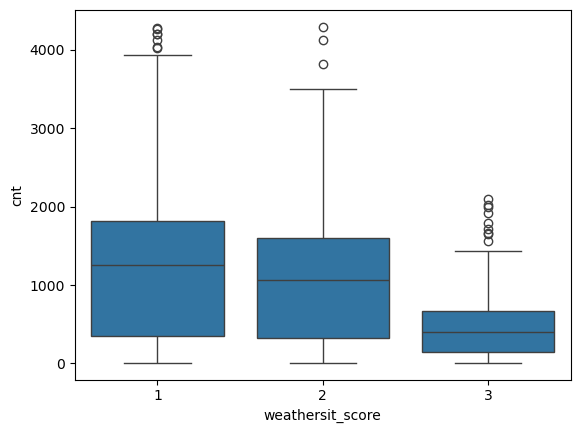

In [24]:
# boxplot of weathersit_score and total rental count
sns.boxplot(data_clean, x='weathersit_score', y='cnt');

Observations:
1. As the weather becomes worse (higher weathersit_score), bike rentals' average and median decrease, and there are fewer outliers.
2. Favorable weather conditions (lower weathersit_score) correspond with the highest number of bike rentals, with a wider range of values, suggesting that people are more likely to rent bikes on such days.

We realize that although the weather situation has scores 1, 2, 3, 4, the boxplot only shows the weather situation for 1, 2, and 3 but there is no weather condition 4. Weather situation 4 stands for “Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog.” By looking back at the original dataset, we found that there were three cases of weather situation 4, but at the end was averaged out during the data cleaning process.

In [25]:
data[data['weathersit'] == 4]

,dteday,season,mnth,hr,workingday,weathersit,temp,atemp,hum,windspeed,cnt
585,2011-01-26,1,1,16,1,4,0.22,0.20,0.93,0.33,36
8854,2012-01-09,1,1,18,1,4,0.20,0.23,0.86,0.09,164
9123,2012-01-21,1,1,1,0,4,0.14,0.14,0.86,0.19,23


We also want to explore the total bike rental count change over time. Below is a line plot of total rental count based on date.
According to the line plot, the total bike rental count increases from January to May, and decreases from September to December. People tend to rent a bike more in May to September.

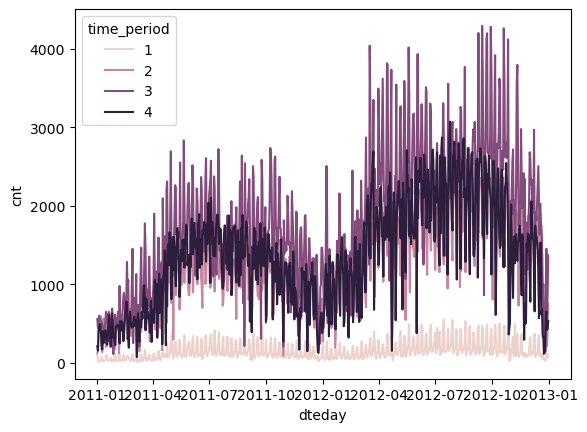

In [26]:
# plot the change of total rental count over time (day)
sns.lineplot(data_clean, x='dteday', y='cnt', hue="time_period");

The graph above is too hard to read, but there is indeed some pattern occured over this time period. We decided to plot based on months.

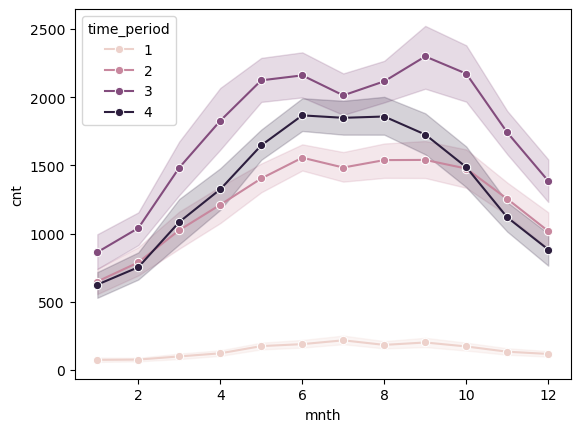

In [27]:
# plot the change of total rental count over time (months)
sns.lineplot(data_clean, x='mnth', y='cnt', hue="time_period", marker='o');

Observations:
1. This graph shows the highest usage of bike rentals are during summer and the lowest during winter. 
2. Time period 3 (afternoon, hour 12-17) consistently sees the most rentals, while time period 1 (dawn, hour 0-5) has the least rentals. 

We want to explore how the change in time of the day can impact the total bike rental count. Below we calculated the average bike rental count for each time period of the day and produced a boxplot of total bike rental count based on time period.
According to the boxplot, people are most likely to rent a bike during afternoons and very unlikely to rent a bike during dawn time. 

In [28]:
# find the mean of the total rental count for each time period
data_cnt_analyze = duckdb.sql("SELECT time_period, AVG(cnt) AS cnt_avg\
                              FROM data_clean \
                              GROUP BY time_period \
                              ORDER BY time_period").df()
data_cnt_analyze

,time_period,cnt_avg
0,1,146.71
1,2,1248.03
2,3,1770.88
3,4,1354.55


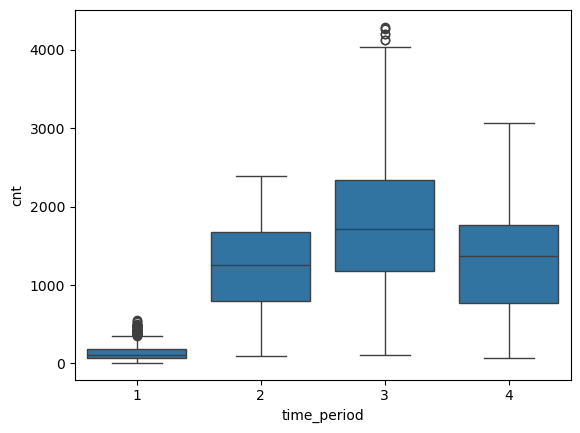

In [29]:
# boxplot of time period and total rental count
sns.boxplot(data_clean, x='time_period', y='cnt');

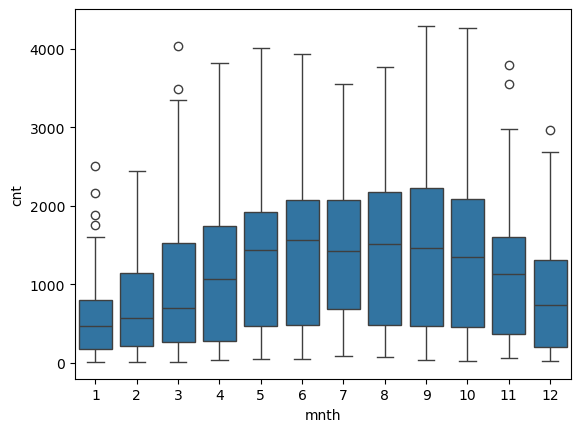

In [30]:
# boxplot of months and total rental count
sns.boxplot(data_clean, x='mnth', y='cnt');

Observations:
1. Time period 3 (afternoon, hour 12-17) corresponds with the highest bike rental counts, while Time period 1 (dawn, hour 0-5)corresponds with the fewest.
2. Summer (June to August) corresponds with the most bike rentals, and winter (December and January) corresponds with the fewest.

## Evaluation of Significance

## Conclusions

## Limitations

## Acknowledgements and Bibliography